# 2.3 Random Forest - Kassel

#### 1. Import libraries
#### 2. Load data
#### 3. Wrangle data
#### 4. Creates Random Forest model
#### 5. Feature importances

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn import metrics
from sklearn.tree import plot_tree
from sklearn import tree

#### 2. Load data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
X=pd.read_csv('/content/drive/MyDrive/7 Machine Learning/Notebooks/Dataset-weather-cleaned.csv')

In [4]:
X.head()

,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,...,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,10.9,1,...,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,10.1,6,...,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,9.9,6,...,4.1,7,0.91,1.0096,0.17,0.08,0.1,10.5,8.1,12.9
3,3,0.92,1.018,0.58,0.00,4.1,6.3,3.8,10.6,8,...,2.3,7,0.86,1.0184,0.13,0.98,0.0,7.4,7.3,10.6
4,6,0.95,1.018,0.65,0.14,5.4,3.0,-0.7,6.0,8,...,4.3,3,0.80,1.0328,0.46,0.00,5.7,5.7,3.0,8.4


In [5]:
X.shape

(22950, 135)

In [6]:
dfa=pd.read_csv(('/content/drive/MyDrive/7 Machine Learning/Notebooks/climate_answers.csv'), index_col=0)

In [7]:
dfa.head()

,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
dfa.shape

(22950, 15)

#### 3. Wrangle data

In [9]:
# Create a list of the columns containing "Kassel" in their names

kassel_list = list(x for x in X.columns if x.find('KASSEL') >=0)
kassel_list

['KASSEL_cloud_cover',
 'KASSEL_humidity',
 'KASSEL_pressure',
 'KASSEL_global_radiation',
 'KASSEL_precipitation',
 'KASSEL_sunshine',
 'KASSEL_temp_mean',
 'KASSEL_temp_min',
 'KASSEL_temp_max']

In [10]:
# Create a dataframe with those columns

df_kassel = X[kassel_list]
df_kassel

,KASSEL_cloud_cover,KASSEL_humidity,KASSEL_pressure,KASSEL_global_radiation,KASSEL_precipitation,KASSEL_sunshine,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max
0,8,0.82,1.0094,0.28,0.48,1.6,7.9,3.9,9.4
1,6,0.86,1.0086,0.12,0.27,0.0,7.7,6.8,9.1
2,8,0.91,1.0129,0.12,0.60,0.0,6.5,6.0,8.0
3,6,0.87,1.0290,0.12,0.00,0.0,5.8,5.2,6.5
4,7,0.86,1.0262,0.13,0.71,0.0,5.4,3.7,6.0
...,...,...,...,...,...,...,...,...,...
22945,4,0.77,1.0161,1.14,0.19,4.0,9.1,5.4,13.1
22946,3,0.77,1.0161,1.14,0.19,4.0,9.1,5.4,13.1
22947,3,0.77,1.0161,1.14,0.19,4.0,9.1,5.4,13.1
22948,3,0.77,1.0161,1.14,0.19,4.0,9.1,5.4,13.1


In [11]:
# Reduce answers dataset to Kassel's answers only

answers_kassel = dfa['KASSEL_pleasant_weather']
answers_kassel

,KASSEL_pleasant_weather
0,0
1,0
2,0
3,0
4,0
...,...
22945,0
22946,0
22947,0
22948,0


In [12]:
# make into X and y data sets

X2 = df_kassel
y2 = answers_kassel

In [13]:
# Turn X2 and y2 from df to arrays

X = np.array(X2)
y = np.array(y2)

In [14]:
X.shape

(22950, 9)

In [15]:
y.shape

(22950,)

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)

In [18]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(17212, 9) (17212,)
(5738, 9) (5738,)


In [ ]:
len(X_train[0])

135

#### 4. Create Random Forest

In [19]:
# creating a RF classifier
clf = RandomForestClassifier(n_estimators = 100)#, max_depth=5)

# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf.fit(X_train, y_train)

RandomForestClassifier()

In [20]:
# performing predictions on the test dataset
y_pred = clf.predict(X_test)

# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  1.0


In [21]:
# performing predictions on the training dataset
y_train_pred = clf.predict(X_train)

# using metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_train, y_train_pred))

Model Accuracy:  1.0


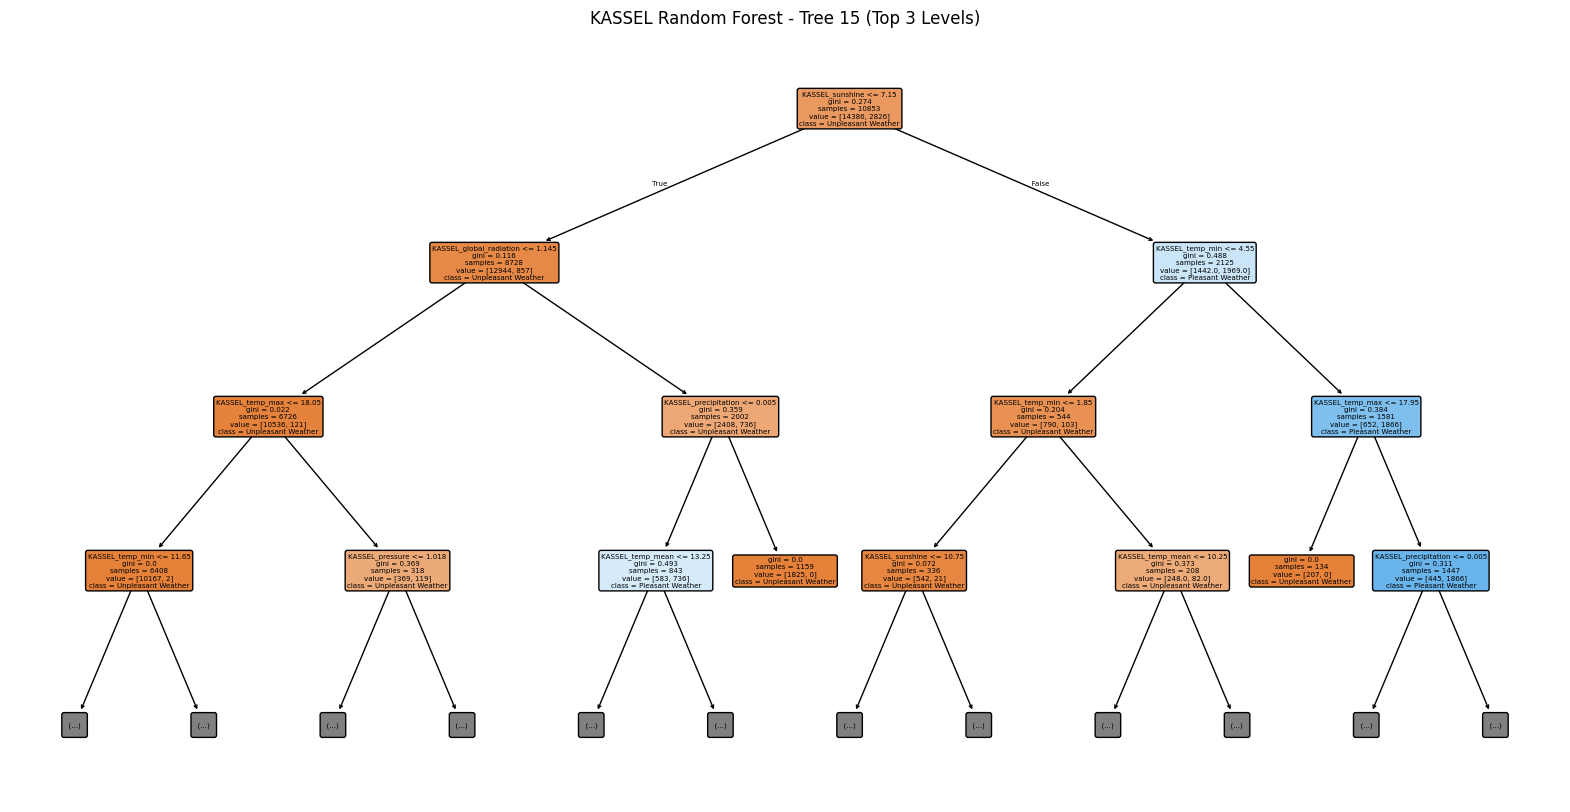

In [22]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the 15th tree from the KASSEL model
plt.figure(figsize=(20, 10))
plot_tree(
    clf.estimators_[15],
    feature_names=df_kassel.columns,
    class_names=["Unpleasant Weather", "Pleasant Weather"],
    filled=True,
    rounded=True,
    max_depth=3                      # Show just top 3 levels to keep it readable
)
plt.title("KASSEL Random Forest - Tree 15 (Top 3 Levels)")
plt.show()

#### 5. Feature importances

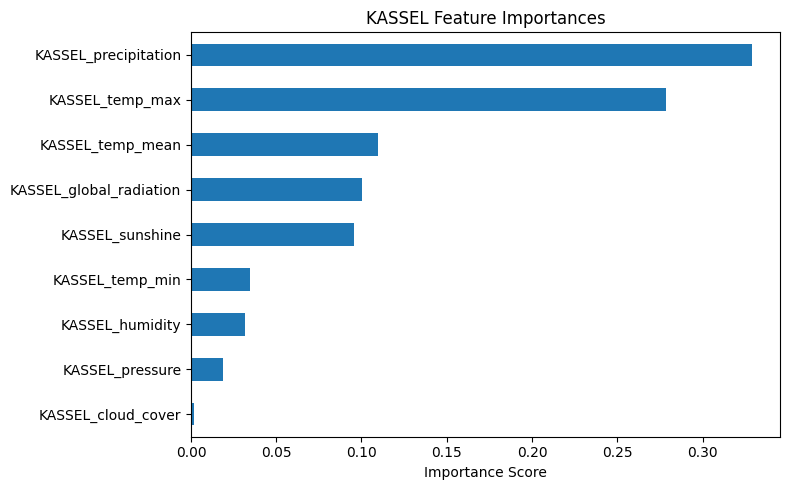

In [23]:
# Create a Series for KASSEL feature importances
importances_kassel = pd.Series(clf.feature_importances_, index=df_kassel.columns)

# Plot top features (all 9 in this case)
importances_kassel.sort_values(ascending=False).plot(kind='barh', figsize=(8, 5))
plt.title("KASSEL Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()  # Show most important at the top
plt.tight_layout()
plt.show()